# K ближайших соседей (KNN)

## Теория

Метод K ближайших соседей (K-Nearest Neighbors, KNN) — это **непараметрический** алгоритм классификации, основанный на принципе **«ленивого обучения»** (lazy learning). Модель не строит явное обобщение на этапе обучения — вместо этого она запоминает всю обучающую выборку и делает предсказания в момент запроса.

### Алгоритм

Для нового объекта $x$:
1. Вычисляются расстояния от $x$ до всех объектов обучающей выборки.
2. Отбираются $K$ ближайших соседей.
3. Класс объекта определяется **голосованием большинства** среди $K$ соседей.

### Метрики расстояния

| Метрика | Формула | Особенности |
|---|---|---|
| **Евклидово** | $d = \sqrt{\sum_i (x_i - y_i)^2}$ | Наиболее распространённая |
| **Манхэттенское** | $d = \sum_i |x_i - y_i|$ | Устойчивее к выбросам |
| **Минковского** | $d = (\sum_i |x_i - y_i|^p)^{1/p}$ | Обобщение двух предыдущих |

## Датасет

В работе используется датасет **Iris** из библиотеки `sklearn`.

Классический набор данных, содержащий измерения цветков ириса трёх видов. Датасет был опубликован Рональдом Фишером в 1936 году и является одним из наиболее известных в машинном обучении.

В датасете:
- **150 объектов** — образцы цветков (по 50 на каждый вид),
- **4 признака** — морфологические измерения цветка (в см),
- **3 класса** — виды ириса.

### Описание признаков

| Признак | Перевод | Описание |
|---|---|---|
| **sepal length (cm)** | длина чашелистика | длина наружного листочка околоцветника |
| **sepal width (cm)** | ширина чашелистика | ширина наружного листочка околоцветника |
| **petal length (cm)** | длина лепестка | длина внутреннего листочка околоцветника |
| **petal width (cm)** | ширина лепестка | ширина внутреннего листочка околоцветника |

### Описание классов

| Класс | Название | Особенности |
|---|---|---|
| **0 — setosa** | ирис щетинистый | самый мелкий вид; лепестки значительно короче и уже, чем у остальных; легко отделяется от двух других классов |
| **1 — versicolor** | ирис разноцветный | промежуточные размеры; частично перекрывается с virginica по признакам |
| **2 — virginica** | ирис виргинский | самый крупный вид; наибольшие длина и ширина лепестков |

Классы сбалансированы: по 50 объектов в каждом. Setosa линейно отделима от остальных, а versicolor и virginica частично перекрываются.

## Используемые библиотеки

В работе используются `numpy`, `pandas`, `matplotlib` и компоненты `sklearn` для классификации методом KNN, масштабирования признаков и оценки качества


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

In [3]:
iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names
target_names = iris.target_names

print("Размер матрицы признаков X:", X.shape)
print("Размер целевой переменной y:", y.shape)
print("\nНазвания признаков:", feature_names)
print("\nНазвания классов:", target_names)

Размер матрицы признаков X: (150, 4)
Размер целевой переменной y: (150,)

Названия признаков: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Названия классов: ['setosa' 'versicolor' 'virginica']


In [4]:
df = pd.DataFrame(X, columns=feature_names)
df["target"] = y

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### Базовые статистики датасета

In [5]:
df.describe().round(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.00,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20,1.00
std,0.83,0.44,1.77,0.76,0.82
min,4.30,2.00,1.00,0.10,0.00
25%,5.10,2.80,1.60,0.30,0.00
50%,5.80,3.00,4.35,1.30,1.00
75%,6.40,3.30,5.10,1.80,2.00
max,7.90,4.40,6.90,2.50,2.00


In [6]:
class_counts = pd.Series(y).value_counts().sort_index()

print("Количество объектов каждого класса:")
for class_id, count in class_counts.items():
    print(f"  {target_names[class_id]} ({class_id}): {count}")

Количество объектов каждого класса:
  setosa (0): 50
  versicolor (1): 50
  virginica (2): 50


### Сравнение классов по средним значениям признаков

In [7]:
class_means = df.groupby("target")[list(feature_names)].mean().T
class_means.columns = [target_names[int(c)] for c in class_means.columns]
class_means = class_means.round(2)

print("Средние значения признаков по классам:\n")
print(class_means.to_string())
print(f"\nSetosa имеет значительно меньшие лепестки (petal), чем остальные два вида.")
print(f"Versicolor и virginica различаются в основном по размерам лепестков и чашелистиков.")

Средние значения признаков по классам:

                   setosa  versicolor  virginica
sepal length (cm)    5.01        5.94       6.59
sepal width (cm)     3.43        2.77       2.97
petal length (cm)    1.46        4.26       5.55
petal width (cm)     0.25        1.33       2.03

Setosa имеет значительно меньшие лепестки (petal), чем остальные два вида.
Versicolor и virginica различаются в основном по размерам лепестков и чашелистиков.


## Тепловая карта

Строим тепловую карту корреляций между признаками датасета `Iris`


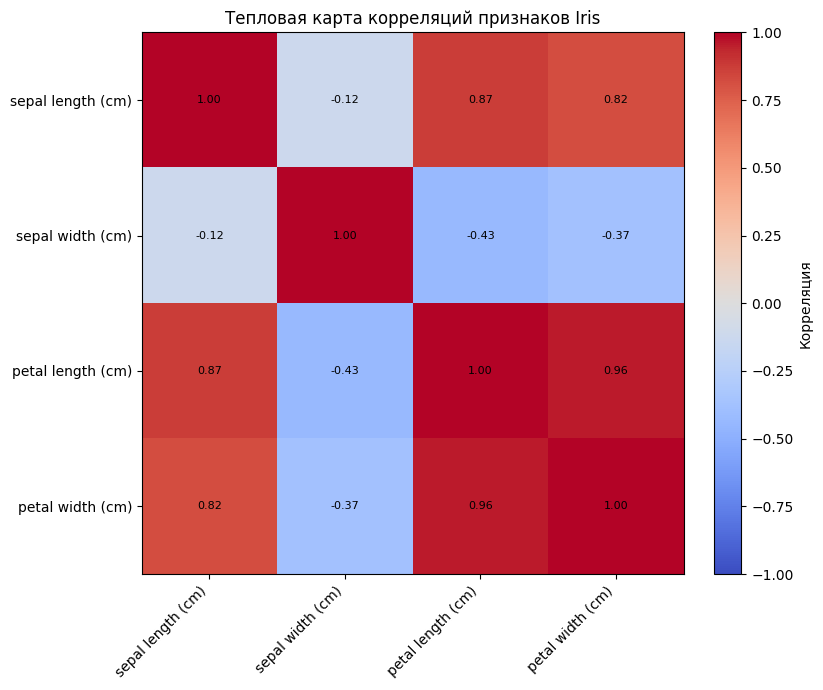

In [8]:
heatmap_features = list(feature_names)
if len(heatmap_features) > 12:
    heatmap_features = heatmap_features[:12]

corr_matrix = df[heatmap_features].corr().round(2)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(heatmap_features)))
ax.set_yticks(range(len(heatmap_features)))
ax.set_xticklabels(heatmap_features, rotation=45, ha='right')
ax.set_yticklabels(heatmap_features)
ax.set_title('Тепловая карта корреляций признаков Iris')

for i in range(len(heatmap_features)):
    for j in range(len(heatmap_features)):
        ax.text(j, i, f"{corr_matrix.values[i, j]:.2f}", ha='center', va='center', color='black', fontsize=8)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Корреляция')
plt.tight_layout()
plt.show()


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)

Размер обучающей выборки: (120, 4)
Размер тестовой выборки: (30, 4)


## Масштабирование признаков

Используем `StandardScaler` для приведения признаков к единому масштабу.

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Среднее по признакам (train, до):  ", np.round(X_train.mean(axis=0), 2))
print("Среднее по признакам (train, после):", np.round(X_train_scaled.mean(axis=0), 2))
print("\nСтд. откл. по признакам (train, после):", np.round(X_train_scaled.std(axis=0), 2))

Среднее по признакам (train, до):   [5.84 3.05 3.77 1.2 ]
Среднее по признакам (train, после): [-0. -0.  0.  0.]

Стд. откл. по признакам (train, после): [1. 1. 1. 1.]


## Обучение KNN (K=5)

In [11]:
knn_model = KNeighborsClassifier(
    n_neighbors=5,         # количество соседей
    weights='uniform',     # все соседи равнозначны
    metric='euclidean'     # евклидова метрика
)

knn_model.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


## Прогнозы модели

Сравниваем предсказанные и истинные классы на тестовой выборке


In [12]:
y_pred = knn_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

Accuracy: 0.9333

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



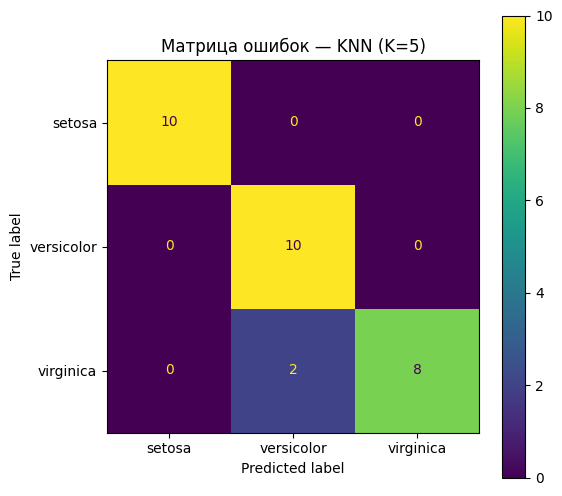

In [13]:
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=target_names,
    ax=ax
)
plt.title("Матрица ошибок — KNN (K=5)")
plt.show()

## Подбор оптимального K

Переберём значения K от 1 до 30 и найдём оптимальное.

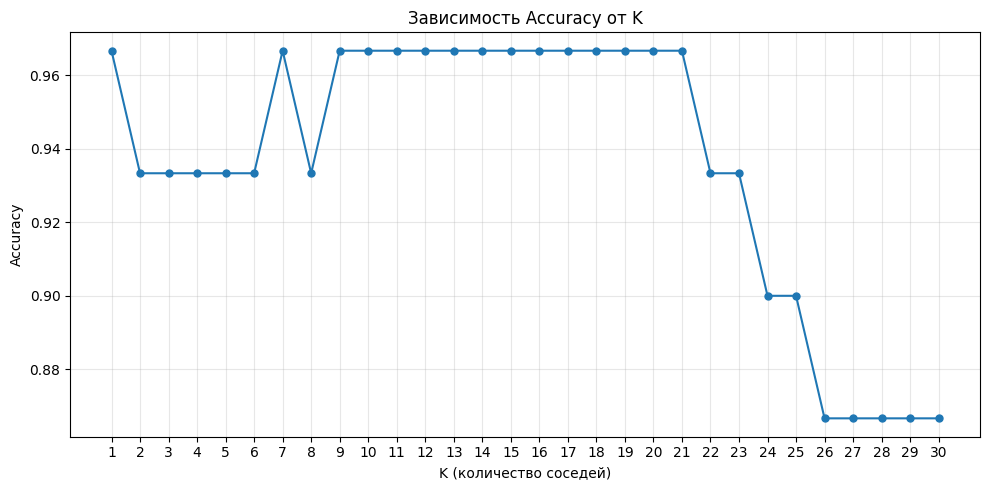

Лучшее K: 1, Accuracy: 0.9667


In [14]:
k_range = range(1, 31)
accuracies = []

for k in k_range:
    model = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    model.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, model.predict(X_test_scaled))
    accuracies.append(acc)

plt.figure(figsize=(10, 5))
plt.plot(k_range, accuracies, marker='o', markersize=5)
plt.xlabel('K (количество соседей)')
plt.ylabel('Accuracy')
plt.title('Зависимость Accuracy от K')
plt.xticks(list(k_range))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_k = list(k_range)[np.argmax(accuracies)]
print(f"Лучшее K: {best_k}, Accuracy: {max(accuracies):.4f}")

## Сравнение метрик расстояния

Сравним евклидово, манхэттенское и расстояние Минковского (p=3) при оптимальном K.

In [15]:
metrics_to_try = {
    'euclidean': {},
    'manhattan': {},
    'minkowski (p=3)': {'metric': 'minkowski', 'p': 3},
}

print(f"Сравнение метрик расстояния при K={best_k}:\n")

for name, params in metrics_to_try.items():
    if 'metric' not in params:
        params['metric'] = name
    model = KNeighborsClassifier(n_neighbors=best_k, **params)
    model.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, model.predict(X_test_scaled))
    print(f"  {name:20s} — Accuracy: {acc:.4f}")

Сравнение метрик расстояния при K=1:

  euclidean            — Accuracy: 0.9667
  manhattan            — Accuracy: 0.9667
  minkowski (p=3)      — Accuracy: 0.9667


## Визуализация границ решений (2D-проекция)

Для наглядности возьмём два признака и визуализируем области решений KNN.

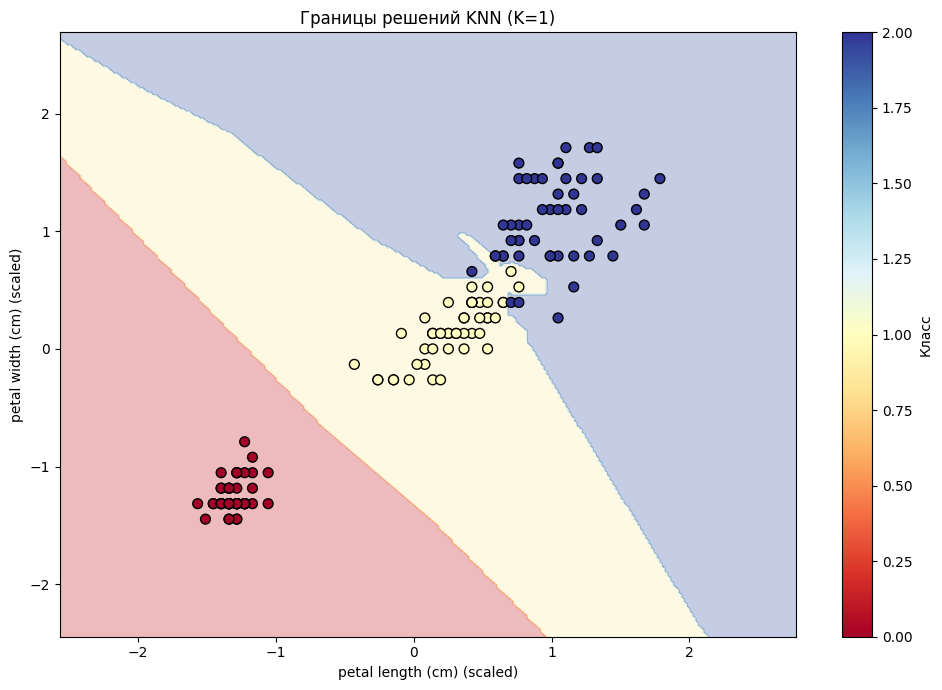

In [16]:
X_2d = X[:, 2:4]
X_2d_scaled = StandardScaler().fit_transform(X_2d)

knn_2d = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
knn_2d.fit(X_2d_scaled, y)

h = 0.02
x_min, x_max = X_2d_scaled[:, 0].min() - 1, X_2d_scaled[:, 0].max() + 1
y_min, y_max = X_2d_scaled[:, 1].min() - 1, X_2d_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
scatter = plt.scatter(X_2d_scaled[:, 0], X_2d_scaled[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolor='black', s=50)
plt.xlabel(feature_names[2] + ' (scaled)')
plt.ylabel(feature_names[3] + ' (scaled)')
plt.title(f'Границы решений KNN (K={best_k})')
plt.colorbar(scatter, label='Класс')
plt.tight_layout()
plt.show()

## Влияние масштабирования



In [17]:
knn_noscale = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
knn_noscale.fit(X_train, y_train) 
acc_noscale = accuracy_score(y_test, knn_noscale.predict(X_test))

knn_scale = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
knn_scale.fit(X_train_scaled, y_train)
acc_scale = accuracy_score(y_test, knn_scale.predict(X_test_scaled))

print(f"Accuracy без масштабирования: {acc_noscale:.4f}")
print(f"Accuracy с масштабированием:  {acc_scale:.4f}")

Accuracy без масштабирования: 0.9667
Accuracy с масштабированием:  0.9667
